<a href="https://colab.research.google.com/github/swornim07/AI-and-Machine-Learning/blob/main/Worksheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Name: Swornim Shrestha
###ID: 2407724

## Task 1: Data Understanding and Visualization

Load and visualize images from the dataset stored in directories, where each sub-directory represents a class.

What I need to do:
- get the list of class directories from the train folder
- select one random image from each class
- display the images in a grid format with two rows using matplotlib

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Classes found in train folder:
['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


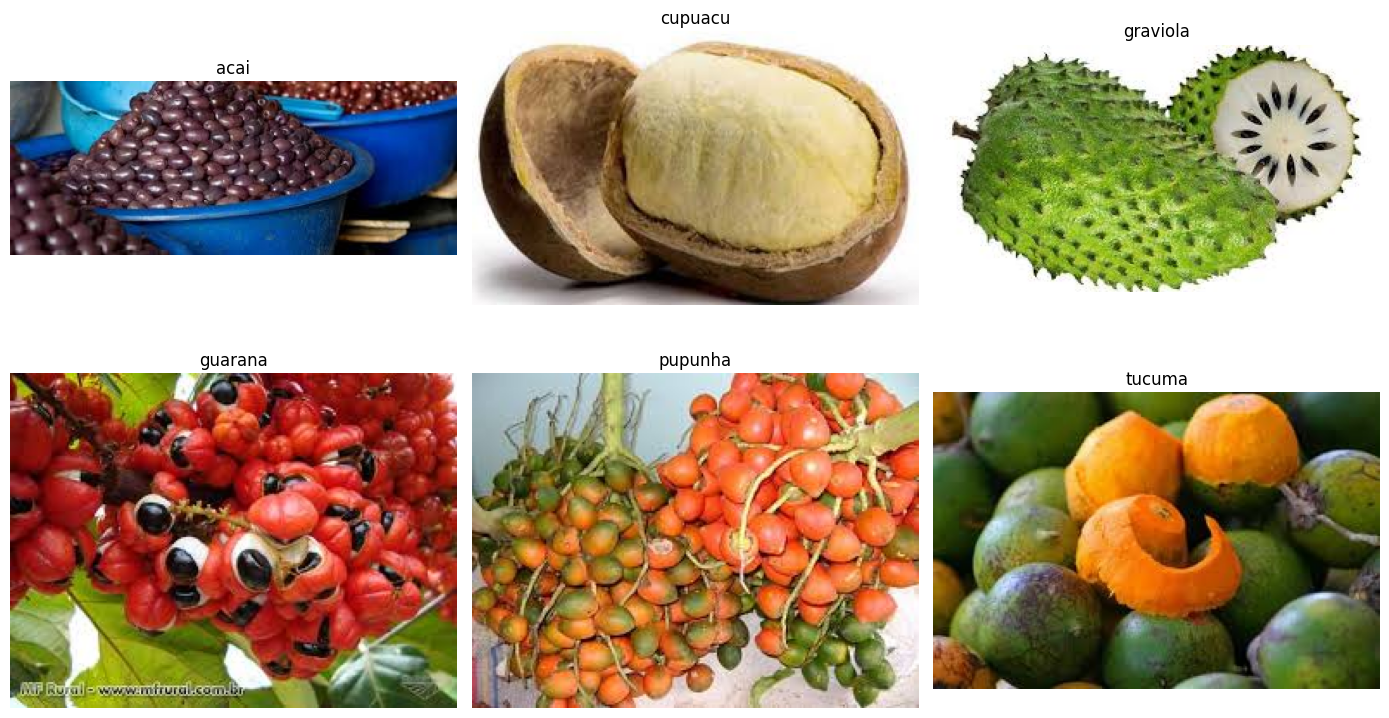

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive

project_dir = '/content/drive/MyDrive/'
dataset_dir = os.path.join(project_dir, 'FruitinAmazon')
train_dir = os.path.join(dataset_dir, 'train')
test_dir = os.path.join(dataset_dir, 'test')

class_names = sorted(os.listdir(train_dir))
print('Classes found in train folder:')
print(class_names)

# picking one random image from each class
random.seed(42)
sample_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    image_list = os.listdir(class_path)
    chosen_image = random.choice(image_list)
    sample_images.append((class_name, os.path.join(class_path, chosen_image)))

# showing the images in 2 rows
rows = 2
cols = 3
plt.figure(figsize=(14, 8))

for i, (class_name, image_path) in enumerate(sample_images):
    plt.subplot(rows, cols, i + 1)
    img = Image.open(image_path)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Observation: What did you observe?

From the images, I observed that the dataset has six different Amazon fruit classes. The images are not all in the same size and the backgrounds are also different, so the dataset is not fully uniform. Some fruits look visually similar, which means the CNN will need to learn color, shape, and texture features properly. This also shows why resizing and normalization are important before training the model.

## Task 2: Check for Corrupted Images

Write a script that verifies whether the images in the train directory are valid. If any corrupted images are found, remove them and print the message showing which image was removed. If none are found, print `No Corrupted Images Found.`

In [3]:
from PIL import Image

corrupted_images = []

# going through each class folder one by one
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        try:
            with Image.open(image_path) as img:
                img.verify()
        except (IOError, SyntaxError, OSError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f'Removed corrupted image: {image_path}')

if len(corrupted_images) == 0:
    print('No Corrupted Images Found.')
else:
    print('\nTotal corrupted images removed:', len(corrupted_images))

No Corrupted Images Found.


## Task 3: Loading and Preprocessing Image Data in Keras

Load the image data from the directory using Keras, resize the images, batch them, normalize the pixel values, and create training, validation, and test datasets.

In [4]:
import tensorflow as tf
from tensorflow.keras import layers

# setting the image size and batch size
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
seed = 123

# rescaling pixels to 0 and 1
rescale = layers.Rescaling(1.0 / 255)

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    validation_split=validation_split,
    subset='training',
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    validation_split=validation_split,
    subset='validation',
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE

# applying normalization to each dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y)).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (rescale(x), y)).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (rescale(x), y)).prefetch(buffer_size=AUTOTUNE)

print('Class names:', class_names)
print('Number of classes:', num_classes)

for images, labels in train_ds.take(1):
    print('Image batch shape:', images.shape)
    print('Label batch shape:', labels.shape)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6
Image batch shape: (16, 128, 128, 3)
Label batch shape: (16,)


## Task 4: Implement a CNN

Build a CNN using the given structure and hyper-parameters:
- Conv2D with 32 filters, `(3, 3)`, `same` padding, stride `1`, ReLU
- MaxPooling2D with pool size `(2, 2)`, stride `2`
- Conv2D with 32 filters, `(3, 3)`, `same` padding, stride `1`, ReLU
- MaxPooling2D with pool size `(2, 2)`, stride `2`
- Flatten layer
- Dense layers with `64` and `128` neurons
- Output layer with number of neurons equal to the number of classes

In [5]:
model = tf.keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# printing the model summary so it is easy to check the layers
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 5: Compile and Train the Model

Compile the model using a suitable optimizer, loss function, and evaluation metric. Then train the model using `model.fit()` with batch size `16`, epochs `250`, validation data, and callbacks such as `ModelCheckpoint` and `EarlyStopping`.

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.1691 - loss: 1.9596
Epoch 1: val_loss improved from None to 1.90606, saving model to /content/drive/MyDrive/best_fruit_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 361ms/step - accuracy: 0.1944 - loss: 1.9372 - val_accuracy: 0.0000e+00 - val_loss: 1.9061
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.2566 - loss: 1.7327
Epoch 2: val_loss improved from 1.90606 to 1.69737, saving model to /content/drive/MyDrive/best_fruit_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 357ms/step - accuracy: 0.2778 - loss: 1.6999 - val_accuracy: 0.2222 - val_loss: 1.6974
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.3316 - loss: 1.5339
Epoch 3: val_loss improved from 1.69737 to 1.63058, saving model to /content/drive/MyDrive/best_fruit_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 324ms/step - accuracy: 0.3611 - loss: 1.4600 - val_accuracy: 0.0000e+00 - val_loss: 1.6306
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.4420 - loss: 1.2464
Epoch 4: val_loss improved from 1.63058 to 1.52761, saving model to /content/drive/MyDrive/best_fruit_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 527ms/step - accuracy: 0.5278 - loss: 1.1727 - val_accuracy: 0.2222 - val_loss: 1.5276
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.7337 - loss: 0.8933
Epoch 5: val_loss improved from 1.52761 to 1.01312, saving model to /content/drive/MyDrive/best_fruit_model.h5


...


Epoch 6: finished saving model to /content/drive/MyDrive/best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 306ms/step - accuracy: 0.8194 - loss: 0.6151 - val_accuracy: 0.6667 - val_loss: 0.8720
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.8781 - loss: 0.4335
Epoch 7: val_loss improved from 0.87198 to 0.80337, saving model to /content/drive/MyDrive/best_fruit_model.h5



Epoch 7: finished saving model to /content/drive/MyDrive/best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 312ms/step - accuracy: 0.8750 - loss: 0.4919 - val_accuracy: 0.7222 - val_loss: 0.8034
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.9372 - loss: 0.2799
Epoch 8: val_loss improved from 0.80337 to 0.65790, saving model to /content/drive/MyDrive/best_fruit_model.h5



Epoch 8: finished saving model to /content/drive/MyDrive/best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - accuracy: 0.8889 - loss: 0.3182 - val_accuracy: 0.7222 - val_loss: 0.6579
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.9351 - loss: 0.2437
Epoch 9: val_loss improved from 0.65790 to 0.51286, saving model to /content/drive/MyDrive/best_fruit_model.h5



Epoch 9: finished saving model to /content/drive/MyDrive/best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 310ms/step - accuracy: 0.9306 - loss: 0.2451 - val_accuracy: 0.8889 - val_loss: 0.5129
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9899 - loss: 0.1071
Epoch 10: val_loss did not improve from 0.51286
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 289ms/step - accuracy: 0.9861 - loss: 0.1165 - val_accuracy: 0.8889 - val_loss: 0.5175
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9899 - loss: 0.0669
Epoch 11: val_loss improved from 0.51286 to 0.30380, saving model to /content/drive/MyDrive/best_fruit_model.h5



Epoch 11: finished saving model to /content/drive/MyDrive/best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 446ms/step - accuracy: 0.9861 - loss: 0.0745 - val_accuracy: 0.8889 - val_loss: 0.3038
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 1.0000 - loss: 0.0332
Epoch 12: val_loss did not improve from 0.30380
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 479ms/step - accuracy: 1.0000 - loss: 0.0361 - val_accuracy: 0.8333 - val_loss: 0.5050
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 1.0000 - loss: 0.0219
Epoch 13: val_loss did not improve from 0.30380
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 314ms/step - accuracy: 1.0000 - loss: 0.0209 - val_accuracy: 0.8889 - val_loss: 0.5199
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 1.0000 - loss: 0.0163
Epoch 14: val_loss did not improve from 0.30380
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 278ms/step - accuracy: 1.0000 - loss: 0.0162 - val_accuracy: 0.8889 - val_loss: 0.3980
Epoch 15/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accur

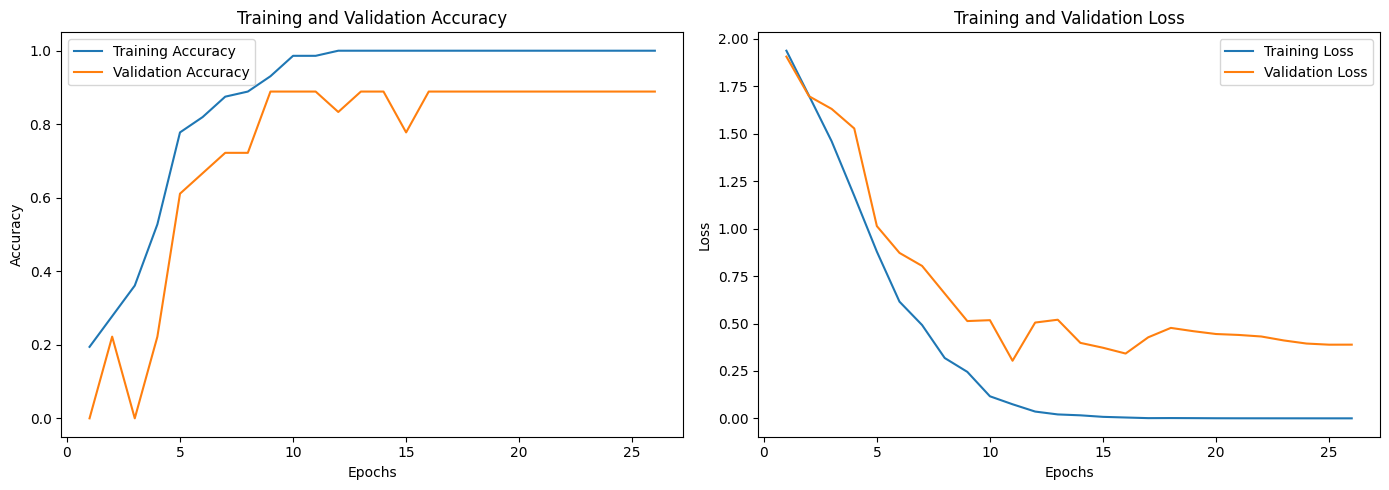

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# compiling the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# saving the best model during training
best_model_path = os.path.join(project_dir, 'best_fruit_model.h5')

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    filepath=best_model_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# training the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[early_stopping, model_checkpoint]
)

# plotting training and validation accuracy and loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Task 6: Evaluate, Save, and Load the Model

Evaluate the trained model on the test set. Save the trained model as an `.h5` file, then load it again and re-evaluate it on the test data.

In [7]:
from tensorflow.keras.models import load_model

# checking performance on the test data
test_loss, test_accuracy = model.evaluate(test_ds)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

# saving the final model in h5 format
final_model_path = os.path.join(project_dir, 'fruit_cnn_model.h5')
model.save(final_model_path)
print(f'Model saved at: {final_model_path}')

# loading the saved model and checking again
loaded_model = load_model(final_model_path)
loaded_loss, loaded_accuracy = loaded_model.evaluate(test_ds)

print(f'Loaded Model Test Loss: {loaded_loss:.4f}')
print(f'Loaded Model Test Accuracy: {loaded_accuracy:.4f}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.6667 - loss: 0.7156


Test Loss: 0.7156
Test Accuracy: 0.6667
Model saved at: /content/drive/MyDrive/fruit_cnn_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.6667 - loss: 0.7156
Loaded Model Test Loss: 0.7156
Loaded Model Test Accuracy: 0.6667


## Task 7: Predictions and Classification Report

Use the trained model to make predictions on the test images. Convert the predicted probabilities to class labels using `np.argmax()` and display the classification report using `classification_report`.

Classification Report:

              precision    recall  f1-score   support

        acai       0.62      1.00      0.77         5
     cupuacu       1.00      0.60      0.75         5
    graviola       0.71      1.00      0.83         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.67      0.80      0.73         5
      tucuma       0.25      0.20      0.22         5

    accuracy                           0.67        30
   macro avg       0.71      0.67      0.65        30
weighted avg       0.71      0.67      0.65        30



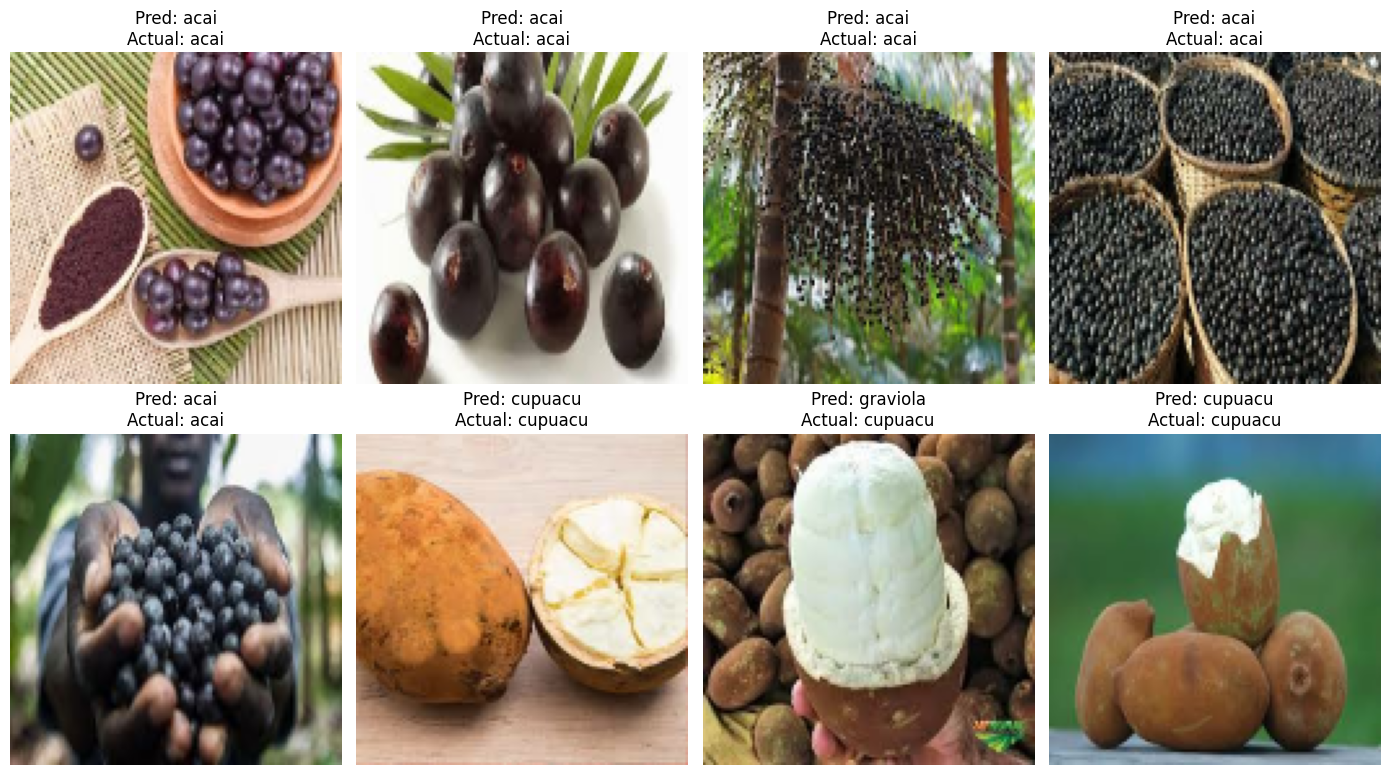

In [8]:
from sklearn.metrics import classification_report

true_labels = []
predicted_labels = []

# getting predictions batch by batch from the test set
for images, labels in test_ds:
    predictions = loaded_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    true_labels.extend(labels.numpy())
    predicted_labels.extend(predicted_classes)

print('Classification Report:\n')
print(classification_report(true_labels, predicted_labels, target_names=class_names))

# showing a few predictions just to see how the model is doing
for images, labels in test_ds.take(1):
    sample_predictions = loaded_model.predict(images, verbose=0)
    sample_predicted_classes = np.argmax(sample_predictions, axis=1)

    plt.figure(figsize=(14, 8))
    for i in range(min(8, len(images))):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"Pred: {class_names[sample_predicted_classes[i]]}\nActual: {class_names[int(labels[i])]}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()